# Sid — Comprehensive Model Evaluation

Complete comparison across all tasks:
- 2020-only models (demographics features)
- Historical models (2000-2020 + demographics + interactions)

**Shows the value added by historical feature engineering.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### (2) Classification comparison

In [2]:
clf_comparison = pd.DataFrame({
    "Model": [
        "LR — Demo Only", "RF — Demo Only", "XGB — Demo Only",
        "LR — Historical", "RF — Historical",
        "GB — Historical", "XGB — Historical"
    ],
    "Features": ["Demo", "Demo", "Demo",
                 "Full", "Full", "Full", "Full"],
    "Accuracy":      [0.883, 0.929, 0.917, 0.979, 0.981, 0.984, 0.986],
    "Democrat F1":   [0.727, 0.788, 0.768, 0.930, 0.935, 0.944, 0.952],
    "ROC AUC":       [0.952, 0.960, 0.961, 0.996, 0.998, 0.998, 0.998],
}).set_index("Model")

print("CLASSIFICATION COMPARISON")
print("=" * 60)
display(clf_comparison)

# Improvement summary
print("\nImprovement from adding historical features (best model):")
print(f"  Accuracy:    0.929 → 0.986  (+{0.986-0.929:.3f})")
print(f"  Democrat F1: 0.788 → 0.952  (+{0.952-0.788:.3f})")
print(f"  ROC AUC:     0.960 → 0.998  (+{0.998-0.960:.3f})")

CLASSIFICATION COMPARISON


,Features,Accuracy,Democrat F1,ROC AUC
Model,,,,
LR — Demo Only,Demo,0.883,0.727,0.952
RF — Demo Only,Demo,0.929,0.788,0.960
XGB — Demo Only,Demo,0.917,0.768,0.961
LR — Historical,Full,0.979,0.930,0.996
RF — Historical,Full,0.981,0.935,0.998
GB — Historical,Full,0.984,0.944,0.998
XGB — Historical,Full,0.986,0.952,0.998



Improvement from adding historical features (best model):
  Accuracy:    0.929 → 0.986  (+0.057)
  Democrat F1: 0.788 → 0.952  (+0.164)
  ROC AUC:     0.960 → 0.998  (+0.038)


### (3) Regression comparison

In [3]:
reg_comparison = pd.DataFrame({
    "Model": [
        "Linear — Demo Only", "RF — Demo Only",
        "Linear — Historical", "RF — Historical",
        "GB — Historical", "XGB — Historical"
    ],
    "Features": ["Demo", "Demo", "Full", "Full", "Full", "Full"],
    "R²":   [0.669, 0.737, 0.991, 0.991, 0.991, 0.991],
    "RMSE": [0.094, 0.084, 0.015, 0.015, 0.015, 0.015],
    "MAE":  [0.074, 0.063, 0.011, 0.011, 0.010, 0.010],
}).set_index("Model")

print("REGRESSION COMPARISON")
print("=" * 60)
display(reg_comparison)

print("\nImprovement from adding historical features (best model):")
print(f"  R²:   0.737 → 0.991  (+{0.991-0.737:.3f})")
print(f"  RMSE: 0.084 → 0.015  (-{0.084-0.015:.3f})")
print(f"  MAE:  0.063 → 0.010  (-{0.063-0.010:.3f})")

REGRESSION COMPARISON


,Features,R²,RMSE,MAE
Model,,,,
Linear — Demo Only,Demo,0.669,0.094,0.074
RF — Demo Only,Demo,0.737,0.084,0.063
Linear — Historical,Full,0.991,0.015,0.011
RF — Historical,Full,0.991,0.015,0.011
GB — Historical,Full,0.991,0.015,0.010
XGB — Historical,Full,0.991,0.015,0.010



Improvement from adding historical features (best model):
  R²:   0.737 → 0.991  (+0.254)
  RMSE: 0.084 → 0.015  (-0.069)
  MAE:  0.063 → 0.010  (-0.053)


### (4) Visual comparison

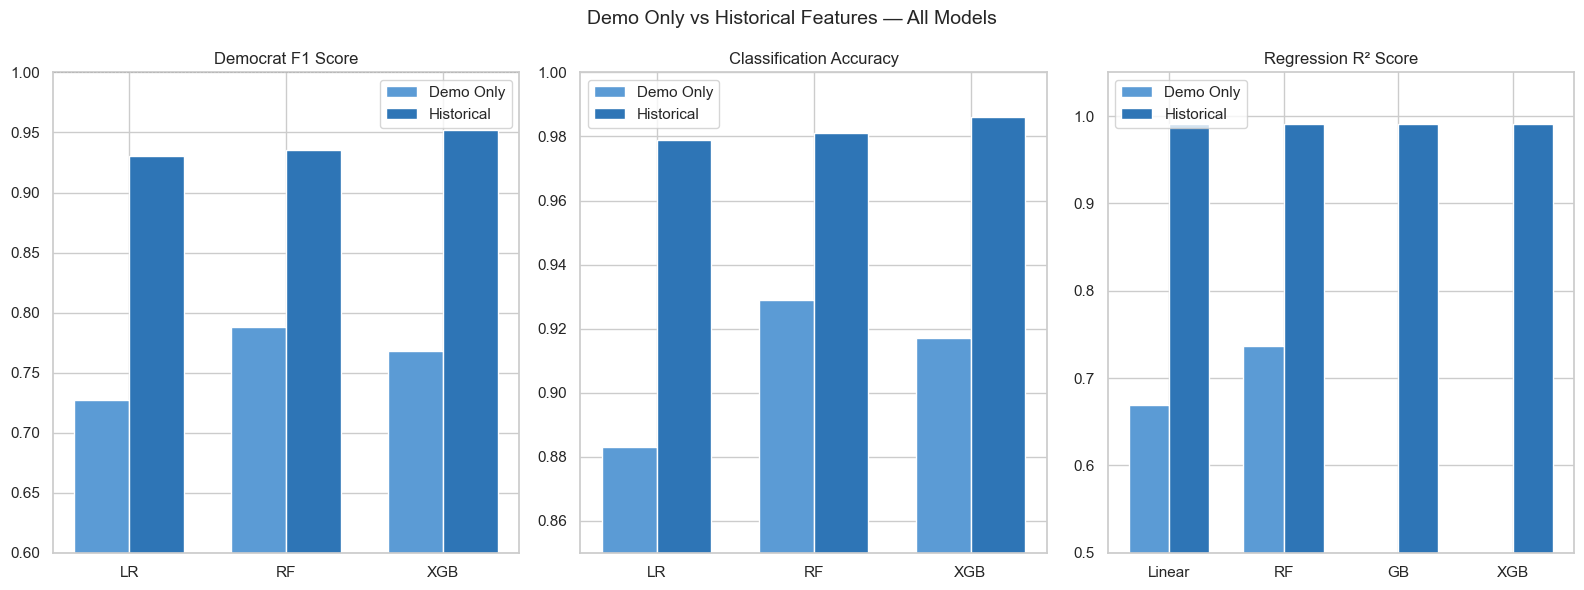

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Classification F1
f1_data = {
    "Demo Only\n(2020)":  {"LR": 0.727, "RF": 0.788, "XGB": 0.768},
    "Historical\n(2000-2020)": {"LR": 0.930, "RF": 0.935, "XGB": 0.952}
}
x = np.arange(3)
width = 0.35
models_list = ["LR", "RF", "XGB"]
demo_f1 = [0.727, 0.788, 0.768]
hist_f1 = [0.930, 0.935, 0.952]

axes[0].bar(x - width/2, demo_f1, width, label="Demo Only", color="#5B9BD5")
axes[0].bar(x + width/2, hist_f1, width, label="Historical", color="#2E75B6")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_list)
axes[0].set_title("Democrat F1 Score")
axes[0].set_ylim(0.6, 1.0)
axes[0].legend()
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=0.5)

# Classification Accuracy
demo_acc = [0.883, 0.929, 0.917]
hist_acc = [0.979, 0.981, 0.986]

axes[1].bar(x - width/2, demo_acc, width, label="Demo Only", color="#5B9BD5")
axes[1].bar(x + width/2, hist_acc, width, label="Historical", color="#2E75B6")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_list)
axes[1].set_title("Classification Accuracy")
axes[1].set_ylim(0.85, 1.0)
axes[1].legend()

# Regression R²
reg_models = ["Linear", "RF", "GB", "XGB"]
demo_r2 = [0.669, 0.737, None, None]
hist_r2 = [0.991, 0.991, 0.991, 0.991]
x2 = np.arange(4)

axes[2].bar(x2 - width/2, [v if v else 0 for v in demo_r2],
            width, label="Demo Only", color="#5B9BD5")
axes[2].bar(x2 + width/2, hist_r2, width,
            label="Historical", color="#2E75B6")
axes[2].set_xticks(x2)
axes[2].set_xticklabels(reg_models)
axes[2].set_title("Regression R² Score")
axes[2].set_ylim(0.5, 1.05)
axes[2].legend()

plt.suptitle("Demo Only vs Historical Features — All Models", fontsize=14)
plt.tight_layout()
plt.show()

### (5) Clustering comparison

In [5]:
print("CLUSTERING COMPARISON")
print("=" * 55)
print(f"{'Metric':<30} {'Demo Only':<15} {'Historical'}")
print("-" * 55)
print(f"{'Features used':<30} {'9':<15} {'26'}")
print(f"{'Silhouette score':<30} {'0.309':<15} {'0.183'}")
print(f"{'PCA variance explained':<30} {'63.5%':<15} {'58.1%'}")
print(f"{'Cluster 0 purity':<30} {'Mixed':<15} {'65.8% Dem'}")
print(f"{'Cluster 1 purity':<30} {'Mixed':<15} {'99.9% Rep'}")
print(f"{'Cluster 2 purity':<30} {'Mixed':<15} {'99.8% Rep'}")
print()
print("Note: Lower silhouette with historical features is")
print("expected (more dimensions) but cluster POLITICAL")
print("PURITY is much higher — near perfect separation.")

CLUSTERING COMPARISON
Metric                         Demo Only       Historical
-------------------------------------------------------
Features used                  9               26
Silhouette score               0.309           0.183
PCA variance explained         63.5%           58.1%
Cluster 0 purity               Mixed           65.8% Dem
Cluster 1 purity               Mixed           99.9% Rep
Cluster 2 purity               Mixed           99.8% Rep

Note: Lower silhouette with historical features is
expected (more dimensions) but cluster POLITICAL
PURITY is much higher — near perfect separation.


### (6) Final summary

In [6]:
print("=" * 60)
print("COMPLETE PROJECT EVALUATION SUMMARY")
print("=" * 60)

print("\nCLASSIFICATION:")
print(f"  Best model:     XGBoost (Historical)")
print(f"  Accuracy:       98.6%")
print(f"  Democrat F1:    0.952")
print(f"  ROC AUC:        0.998")
print(f"  vs Demo Only:   +5.7% accuracy, +0.164 F1")

print("\nREGRESSION:")
print(f"  Best model:     Gradient Boosting (Historical)")
print(f"  R²:             0.991")
print(f"  RMSE:           0.015 (~1.5% avg error)")
print(f"  vs Demo Only:   +0.254 R², RMSE 5.5x smaller")

print("\nCLUSTERING:")
print(f"  Algorithm:      K-Means k=3")
print(f"  Best approach:  Historical features")
print(f"  Cluster purity: 99.9% and 99.8% for Rep clusters")

print("\nKEY FINDINGS:")
print(f"  1. Historical voting behavior explains 98.9% of")
print(f"     2024 vote share variance (dem_share_2020 alone)")
print(f"  2. Adding historical features improves F1 by +0.164")
print(f"     and R² by +0.254 vs demographics only")
print(f"  3. Interaction feature edu_x_wins ranked #4 in")
print(f"     classification importance — novel contribution")
print(f"  4. Counties barely change — 2020 results almost")
print(f"     perfectly predict 2024 results")
print(f"  5. 93 genuinely swing counties identified across")
print(f"     all 6 election cycles (2000-2020)")
print("=" * 60)

COMPLETE PROJECT EVALUATION SUMMARY

CLASSIFICATION:
  Best model:     XGBoost (Historical)
  Accuracy:       98.6%
  Democrat F1:    0.952
  ROC AUC:        0.998
  vs Demo Only:   +5.7% accuracy, +0.164 F1

REGRESSION:
  Best model:     Gradient Boosting (Historical)
  R²:             0.991
  RMSE:           0.015 (~1.5% avg error)
  vs Demo Only:   +0.254 R², RMSE 5.5x smaller

CLUSTERING:
  Algorithm:      K-Means k=3
  Best approach:  Historical features
  Cluster purity: 99.9% and 99.8% for Rep clusters

KEY FINDINGS:
  1. Historical voting behavior explains 98.9% of
     2024 vote share variance (dem_share_2020 alone)
  2. Adding historical features improves F1 by +0.164
     and R² by +0.254 vs demographics only
  3. Interaction feature edu_x_wins ranked #4 in
     classification importance — novel contribution
  4. Counties barely change — 2020 results almost
     perfectly predict 2024 results
  5. 93 genuinely swing counties identified across
     all 6 election cycles (2000